In [1]:
import sqlite3
#sql built-in
#allow to create,conect db

In [2]:
import pandas as pd
#import pandas for dataframe
#load into database(to_sql)

In [3]:
import matplotlib.pyplot as pyplot
#visual

In [4]:
import warnings
warnings.filterwarnings('ignore')
#small error ignore non-critical warning msg that clutter output
print("All libraries imported successfully")
print(f"pandas version:(pd._version_)")
print(f"sqlite version:(sqlite3.version)")

All libraries imported successfully
pandas version:(pd._version_)
sqlite version:(sqlite3.version)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df=pd.read_csv('student_performance.csv')
#load panda into dataframes first
#then transfer into sqlite database
print("Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")#0 IS ROW 1 IS COLUMN
print(f"Columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [8]:
import sqlite3
conn=sqlite3.connect('college.db')
#conn=our connection to database
#college.db file that wil be created in colab
#college.db already exists it just open it
#if not exists,sqlite create  automatically
c=conn.cursor()

In [9]:
import pandas as pd
df=pd.read_csv('student_performance.csv')

df.to_sql(
    'students',#table create db
    conn,#which db connection is to use
    if_exists='replace',#if students table exists replace it
    index=False)#do not write dataframe row num as a column
c.execute("SELECT COUNT(*) FROM students")
count=c.fetchone()[0]
print("Number of rows inserted into 'students' table",count)

Number of rows inserted into 'students' table 30


In [11]:
#prgma is special sqlite cmd(not standard sql)
#table info()show structure of table
c.execute("PRAGMA table_info(students)")
columns_info=c.fetchall()
#.fetchall()reterive all result from row
print("Table structure of 'student':")
print(f"{'Column Name':<25}{'Datatype':<12}")
print("-" * 38)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")#col1 col name,col2 datatype

Table structure of 'student':
Column Name              Datatype    
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


select col1,col2
from table_name
where condition
Group BY col
HAVING group_condition
ORDER BY co DESC
LIMIT 10;

In [12]:
def run_query(sql,description=""):
  #run sql query
  if description:
    print(f"\n{"="*55}")
    print(f" {description}")
    print(f"{"="*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result
print("Hepler function 'run query' defined successfully")
print("Usage:run query{sql_string,description_index}")

Hepler function 'run query' defined successfully
Usage:run query{sql_string,description_index}


In [13]:
query1="""select student_id,name,department,math_score,attendance_percentage from students limit 10"""
result=run_query(query1,"Query 1:first 10 students(SELECT+LIMIT)")


 Query 1:first 10 students(SELECT+LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [14]:
query2= """
select name,department,math_score
from students
ORDER BY math_score DESC
LIMIT 5
"""
result2=run_query(query2,"query  2: Top 5 math_scores(ORDER BY DESC+LIMIT[5])")


 query  2: Top 5 math_scores(ORDER BY DESC+LIMIT[5])
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [15]:
query3="""
select name,math_score,science_score,programming_score,attendance_percentage
from students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result3=run_query(query3,"Query 3:computer science students(WHERE filter)")
print("\nTotal cs students found(len(result3)")



 Query 3:computer science students(WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79

In [16]:
query4= """
select name,department,attendance_percentage
from students
WHERE attendance_percentage>90
AND department !='civil'
ORDER BY attendance_percentage DESC
"""
result4=run_query(query4,"Query 4:High Attendance(>90),department(!=civil)")


 Query 4:High Attendance(>90),department(!=civil)
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [17]:
query5="""
select
department,
count(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math,
ROUND(AVG(science_score),2) AS avg_science,
ROUND(AVG(programming_score),2) AS avg_programming,
ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
from students
GROUP BY department
ORDER BY avg_math DESC
"""
result5=run_query(query5,"Query 5:Department wise average score")


 Query 5:Department wise average score
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance_percentage
Computer Science            13     85.62        84.46            89.23                      90.69
      Mechanical             6     71.00        76.50            49.33                      83.50
     Electronics             6     71.00        74.17            61.50                      80.33
           Civil             5     63.40        66.60            40.60                      74.60


In [18]:
query6="""
select
department,round(avg(math_score),2) AS avg_math,
count(*) AS students
from students
group by department
having avg(math_score)>70
order by avg_math DESC
"""
result6=run_query(query6,"Query 6:Department wise average score>70")


 Query 6:Department wise average score>70
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [19]:
query7="""
select
gender,count(*) as num_students,
round(avg(math_score),2) as avg_math,
round(avg(programming_score),2) as avg_programming,
round(avg(attendance_percentage),2) as avg_attendance_percentage
from students
group by gender
"""
result7=run_query(query7,"Query 7:gender-wise performanceanalysis")


 Query 7:gender-wise performanceanalysis
gender  num_students  avg_math  avg_programming  avg_attendance_percentage
Female            15     78.47             70.2                      88.53
  Male            15     73.67             65.0                      80.47


In [20]:
query8="""
select
name,
department,
(math_score+science_score+english_score+programming_score) AS total_score,attendance_percentage
from students
order by total_score desc
limit 10
"""
result8=run_query(query8,"Query 8:Top 10 students by total score")


 Query 8:Top 10 students by total score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [21]:
import pandas as pd
#JOIN demontration
dept_data={
    'dept_code': ['CS','EC','ME','CE'],
    'dept_name': ['computer science','electronics','mechanical','civil'],
    'hod_name': ['dr.sharma','dr.siva','dr.kavi','dr.bhuvi'],
    'established':[1901,1988,1922,1933],
    'intake':[60,55,65,67]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))

dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}

# Ensure df is freshly loaded from the CSV before mapping
df=pd.read_csv('student_performance.csv')

# Map the department names in df to department codes
df['department']=df['department'].map(dept_map)

# Now, re-create the 'students' table in the database
# using the updated 'df' so that its 'department' column contains codes
df.to_sql(
    'students',
    conn,
    if_exists='replace', # Replace existing students table
    index=False
)
print("\nUpdated 'students' table with department codes.")
c.execute("SELECT COUNT(*) FROM students")
count=c.fetchone()[0]
print("Number of rows inserted into 'students' table:",count)

Created 'departments' table:
dept_code        dept_name  hod_name  established  intake
       CS computer science dr.sharma         1901      60
       EC      electronics   dr.siva         1988      55
       ME       mechanical   dr.kavi         1922      65
       CE            civil  dr.bhuvi         1933      67

Updated 'students' table with department codes.
Number of rows inserted into 'students' table: 30


In [22]:
query_join="""
select
s.name,
s.math_score,
d.dept_name,
d.hod_name,
d.established
from students as s INNER JOIN departments as d ON s.department = d.dept_code
order by s.math_score desc
limit 8
"""
result_join=run_query(query_join,"JOIN:students with Department details(inner join)")


 JOIN:students with Department details(inner join)
          name  math_score        dept_name  hod_name  established
    Ananya Das          95 computer science dr.sharma         1901
   Tanvi Mehta          93 computer science dr.sharma         1901
    Arjun Nair          92 computer science dr.sharma         1901
Akanksha Yadav          91 computer science dr.sharma         1901
Swati Kulkarni          90 computer science dr.sharma         1901
   Divya Singh          88 computer science dr.sharma         1901
  Ritu Agarwal          87      electronics   dr.siva         1988
     Amit Bose          86 computer science dr.sharma         1901


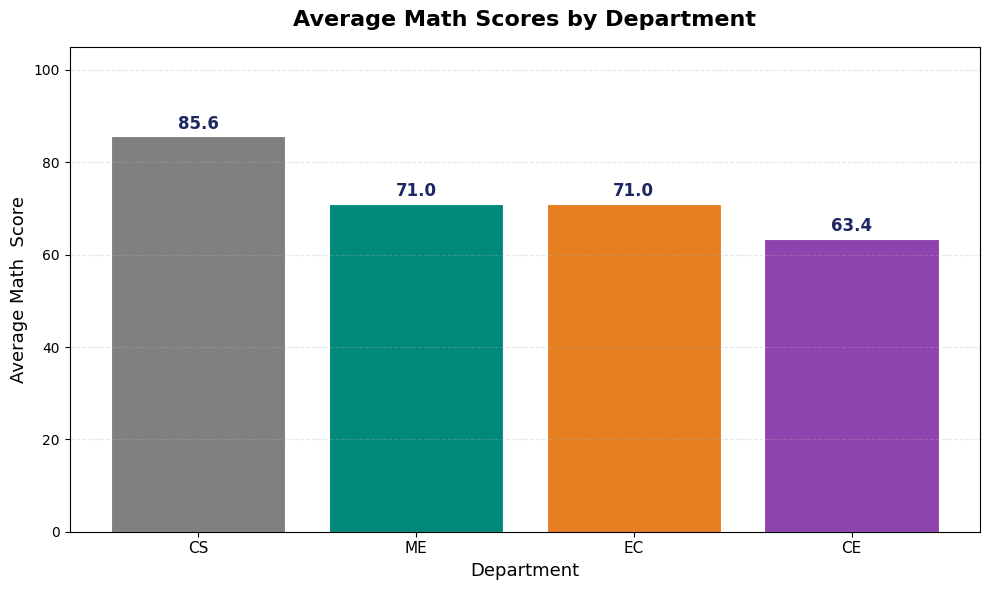

In [23]:
import matplotlib.pyplot as plt
chart1_sql=""" select department,round(avg(math_score),2)as avg_score
from students group by department order by avg_score desc"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_color=['#808080','#00897B','#E67E22','#8E44AD']
bars=ax.bar(chart1_data['department'],chart1_data['avg_score'],color=bar_color,
 edgecolor='white',linewidth=0.8)

for bar in bars:
  height=bar.get_height()
  ax.text(bar.get_x()+bar.get_width()/2,
          height+0.8,
          f'{height:.1f}',
          ha='center', va='bottom',
          fontsize=12,fontweight='bold',color='#1E2761')
ax.set_title('Average Math Scores by Department',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Department',fontsize=13)
ax.set_ylabel('Average Math  Score',fontsize=13)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle= '--')
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
df=pd.DataFrame({
    'category':np.random.choice(['A','B','C','D'],100),
    'value':np.random.randint(10,100,100),
    'score':np.random.randint(50,100,100)
}
)

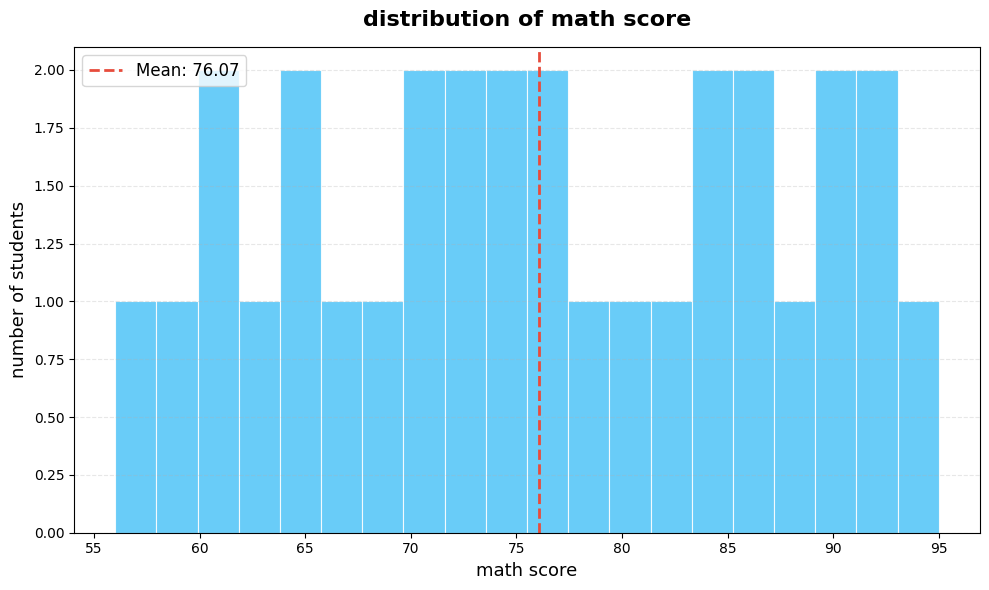

In [25]:
df=pd.read_csv('student_performance.csv')
math_scores=df['math_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    math_scores,
    bins=20,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)

mean_score=sum(math_scores)/len(math_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.2f}'
)

ax.set_title('distribution of math score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('math score',fontsize=13)
ax.set_ylabel('number of students',fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

In [27]:
import plotly.express as px
import pandas as pd
import numpy as np

# Redefine df with 'category' column for this specific chart
df = pd.DataFrame({
    'category': np.random.choice(['A', 'B', 'C', 'D'], 100),
    'value': np.random.randint(10, 100, 100),
    'score': np.random.randint(50, 100, 100)
})

category_counts = df['category'].value_counts().reset_index()

category_counts.columns = ['Category', 'Count']

fig = px.bar(
    category_counts,
    x='Category',
    y='Count',
    color='Category',
    title='Interactive Category Distribution',
    text='Count'
)

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Count'
)

fig.show()

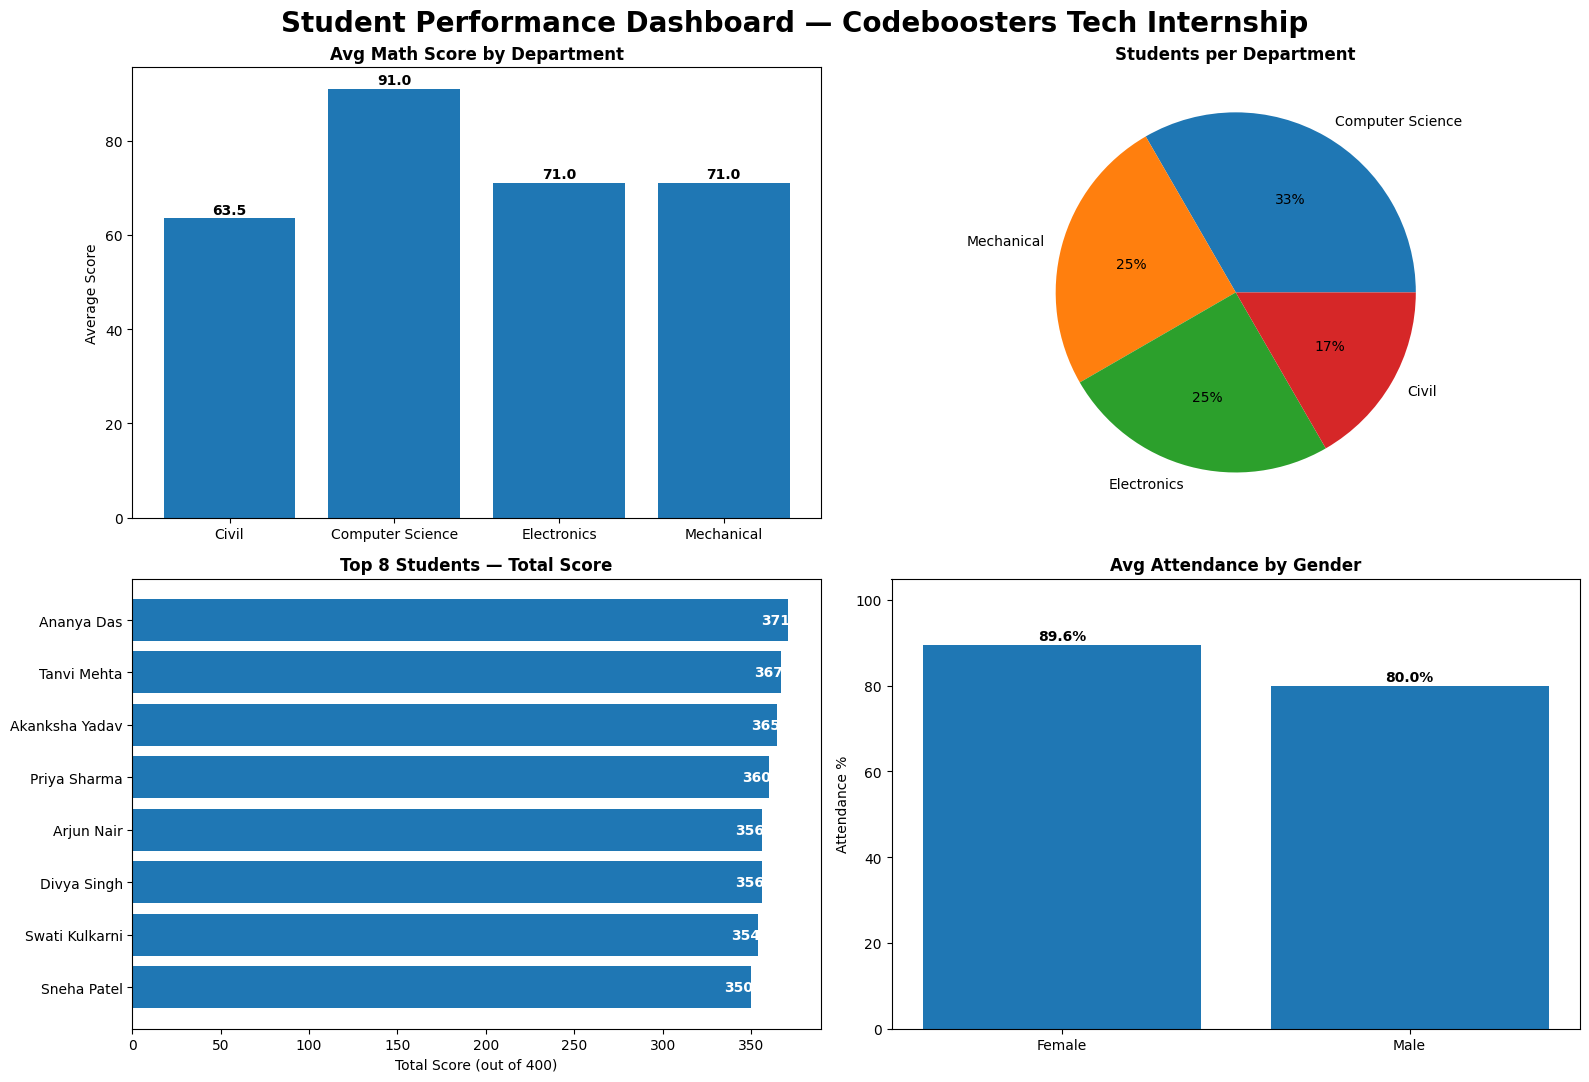

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
data = {
    'name': [
        'Ananya Das', 'Tanvi Mehta', 'Akanksha Yadav',
        'Arjun Nair', 'Divya Singh', 'Swati Kulkarni',
        'Amit Bose', 'Suresh Rao', 'Priya Sharma',
        'Rahul Verma', 'Kiran Kumar', 'Sneha Patel'
    ],

    'gender': [
        'Female', 'Female', 'Female',
        'Male', 'Female', 'Female',
        'Male', 'Male', 'Female',
        'Male', 'Male', 'Female'
    ],

    'department': [
        'Computer Science', 'Mechanical', 'Electronics',
        'Computer Science', 'Computer Science', 'Electronics',
        'Civil', 'Mechanical', 'Computer Science',
        'Civil', 'Electronics', 'Mechanical'
    ],

    'math_score': [
        95, 72, 74,
        88, 90, 68,
        60, 70, 91,
        67, 71, 71
    ],

    'programming_score': [
        94, 92, 93,
        89, 88, 90,
        85, 84, 92,
        75, 80, 87
    ],

    'attendance_percentage': [
        91, 90, 89,
        81, 92, 87,
        79, 82, 93,
        78, 80, 85
    ],

    'total_score': [
        371, 367, 365,
        356, 356, 354,
        336, 334, 360,
        300, 290, 350
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Figure layout
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# Title
fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=20,
    fontweight='bold'
)

# 1. Avg Math Score by Department
dept_avg = df.groupby('department')['math_score'].mean()

bars = axs[0, 0].bar(
    dept_avg.index,
    dept_avg.values
)

axs[0, 0].set_title("Avg Math Score by Department", fontweight='bold')
axs[0, 0].set_ylabel("Average Score")

for bar in bars:
    height = bar.get_height()
    axs[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}',
        ha='center',
        fontweight='bold'
    )

# 2. Students per Department (Pie Chart)
dept_count = df['department'].value_counts()

axs[0, 1].pie(
    dept_count,
    labels=dept_count.index,
    autopct='%1.0f%%'
)

axs[0, 1].set_title("Students per Department", fontweight='bold')

# 3. Top 8 Students
top_students = df.sort_values(
    by='total_score',
    ascending=False
).head(8)

axs[1, 0].barh(
    top_students['name'],
    top_students['total_score']
)

axs[1, 0].invert_yaxis()

axs[1, 0].set_title(
    "Top 8 Students — Total Score",
    fontweight='bold'
)

axs[1, 0].set_xlabel("Total Score (out of 400)")

for i, score in enumerate(top_students['total_score']):
    axs[1, 0].text(
        score - 15,
        i,
        str(score),
        va='center',
        fontweight='bold',
        color='white'
    )

# 4. Avg Attendance by Gender
gender_attendance = df.groupby(
    'gender'
)['attendance_percentage'].mean()

bars = axs[1, 1].bar(
    gender_attendance.index,
    gender_attendance.values
)

axs[1, 1].set_title(
    "Avg Attendance by Gender",
    fontweight='bold'
)

axs[1, 1].set_ylabel("Attendance %")
axs[1, 1].set_ylim(0, 105)

for bar in bars:
    height = bar.get_height()
    axs[1, 1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()